<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8009/blob/main/Semana_5_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#pip install missingno

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# DATOS FALTANTES

En este notebook exploraremos los diferentes tipos de datos faltantes, cómo identificarlos, visualizarlos y tratarlos mediante diversas técnicas de imputación.

## NULL vs VACÍO vs CERO

Es crucial distinguir entre estos tres conceptos, ya que cada uno tiene un significado diferente:

- **NULL (NaN)**: Representa la ausencia de información. Es un valor que indica que no se conoce o no se registró el dato.
- **VACÍO ('')**: Es una cadena de texto sin contenido. Técnicamente es un valor, aunque esté vacío.
- **CERO (0)**: Es un valor numérico explícito que tiene significado (ausencia de cantidad, pero es una información conocida).

Confundir estos conceptos puede llevar a análisis incorrectos. Por ejemplo, si alguien no realizó ninguna venta (0) es diferente a no tener información sobre sus ventas (NaN).

In [ ]:
# Ejemplo visual de las diferencias entre NULL, VACÍO y CERO

# NULL - Valores NaN que representan datos faltantes
df1 = pd.DataFrame({'nombre': ['Ana', np.nan, 'Carlos'], 'ventas': [np.nan, '10', np.nan]})
print("NULL (NaN) - Datos faltantes:")
print(df1)

print('-' * 20)

# VACÍO - Cadenas de texto sin contenido
df2 = pd.DataFrame({'nombre': ['Ana', '', 'Carlos'], 'ventas': ['', '10', '']})
print("VACÍO - Cadenas sin contenido:")
print(df2)

print('-' * 20)

# CERO - Valor numérico explícito
df3 = pd.DataFrame({'nombre': ['Ana', 'Luis', 'Carlos'], 'ventas': [0, 10, 0]})
print("CERO - Valor numérico conocido:")
print(df3)

NULL (NaN) - Datos faltantes:
   nombre ventas
0     Ana    NaN
1     NaN     10
2  Carlos    NaN
--------------------
VACÍO - Cadenas sin contenido:
   nombre ventas
0     Ana       
1             10
2  Carlos       
--------------------
CERO - Valor numérico conocido:
   nombre  ventas
0     Ana       0
1    Luis      10
2  Carlos       0


## Visualización de Datos Faltantes con missingno

La librería `missingno` proporciona visualizaciones intuitivas para identificar patrones de valores faltantes en nuestros datos. Esto nos ayuda a entender:
- Qué columnas tienen más datos faltantes
- Si existen patrones en la ausencia de datos
- Si los valores faltantes están correlacionados entre columnas

In [ ]:
# Cargar dataset de colisiones de NYC
# Este dataset contiene información sobre factores contribuyentes en colisiones vehiculares
collisions = pd.read_csv("https://raw.githubusercontent.com/ResidentMario/missingno-data/master/nyc_collision_factors.csv")
df = collisions.copy()

# Visualizar primeras filas y estructura del dataset
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (7303, 26)

Primeras filas:


,DATE,TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,11/10/2016,16:11:00,BROOKLYN,11208.0,40.662514,-73.872007,"(40.6625139, -73.8720068)",WORTMAN AVENUE,MONTAUK AVENUE,NaN,...,Failure to Yield Right-of-Way,Unspecified,NaN,NaN,NaN,TAXI,PASSENGER VEHICLE,NaN,NaN,NaN
1,11/10/2016,05:11:00,MANHATTAN,10013.0,40.721323,-74.008344,"(40.7213228, -74.0083444)",HUBERT STREET,HUDSON STREET,NaN,...,Failure to Yield Right-of-Way,NaN,NaN,NaN,NaN,PASSENGER VEHICLE,NaN,NaN,NaN,NaN
2,04/16/2016,09:15:00,BROOKLYN,11201.0,40.687999,-73.997563,"(40.6879989, -73.9975625)",HENRY STREET,WARREN STREET,NaN,...,Lost Consciousness,Lost Consciousness,NaN,NaN,NaN,PASSENGER VEHICLE,VAN,NaN,NaN,NaN
3,04/15/2016,10:20:00,QUEENS,11375.0,40.719228,-73.854542,"(40.7192276, -73.8545422)",NaN,NaN,67-64 FLEET STREET,...,Failure to Yield Right-of-Way,Failure to Yield Right-of-Way,Failure to Yield Right-of-Way,NaN,NaN,PASSENGER VEHICLE,PASSENGER VEHICLE,PASSENGER VEHICLE,NaN,NaN
4,04/15/2016,10:35:00,BROOKLYN,11210.0,40.632147,-73.952731,"(40.6321467, -73.9527315)",BEDFORD AVENUE,CAMPUS ROAD,NaN,...,Failure to Yield Right-of-Way,Failure to Yield Right-of-Way,NaN,NaN,NaN,PASSENGER VEHICLE,PASSENGER VEHICLE,NaN,NaN,NaN


<Axes: >

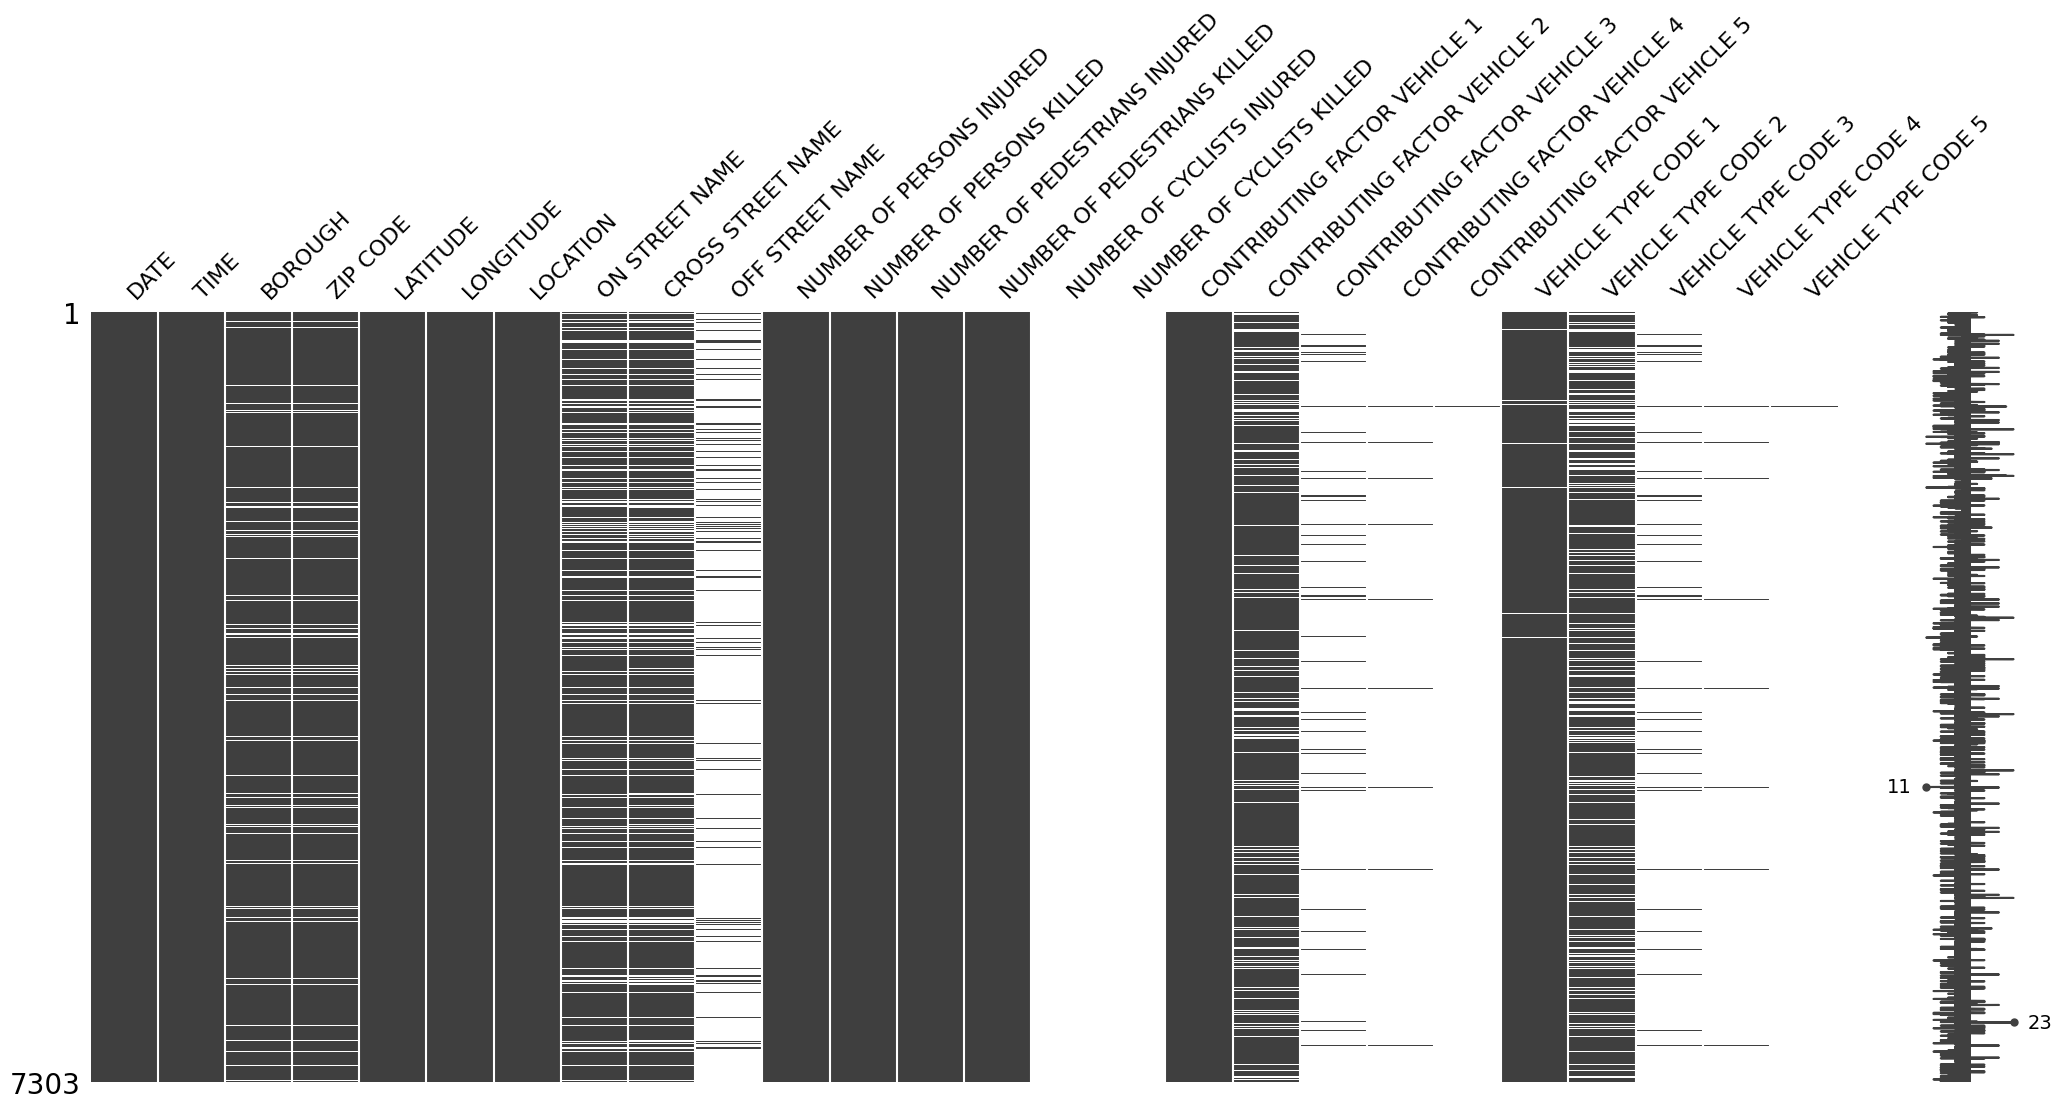

In [ ]:
# Matriz de valores faltantes
# Las barras blancas indican datos presentes, las grises indican valores faltantes
# Útil para visualizar el patrón de completitud de los datos
msno.matrix(df)

<Axes: >

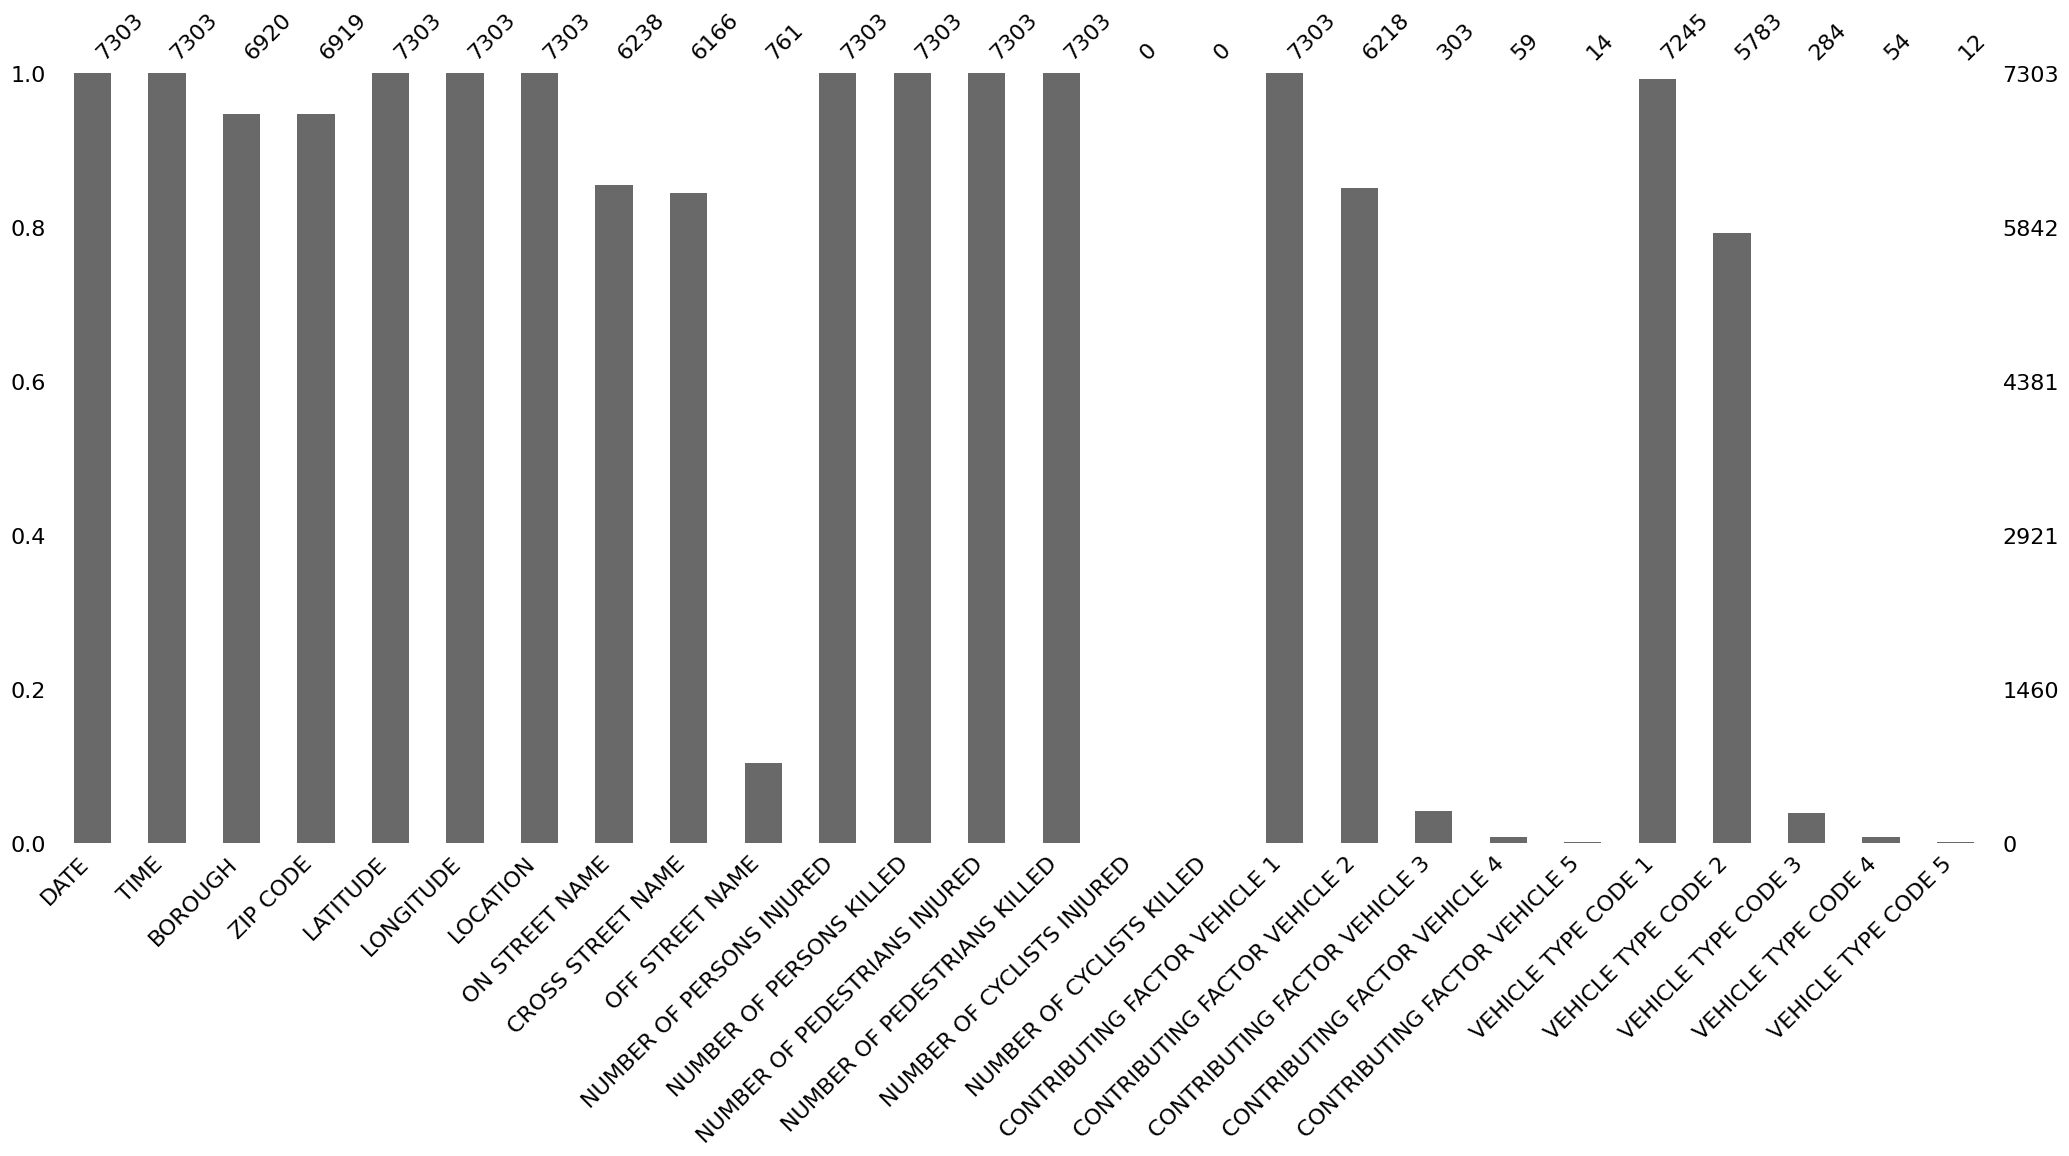

In [ ]:
# Gráfico de barras de valores faltantes por columna
# Muestra cuántos valores no faltantes hay en cada columna
# La línea superior indica el tamaño total del dataset
msno.bar(df)

<Axes: >

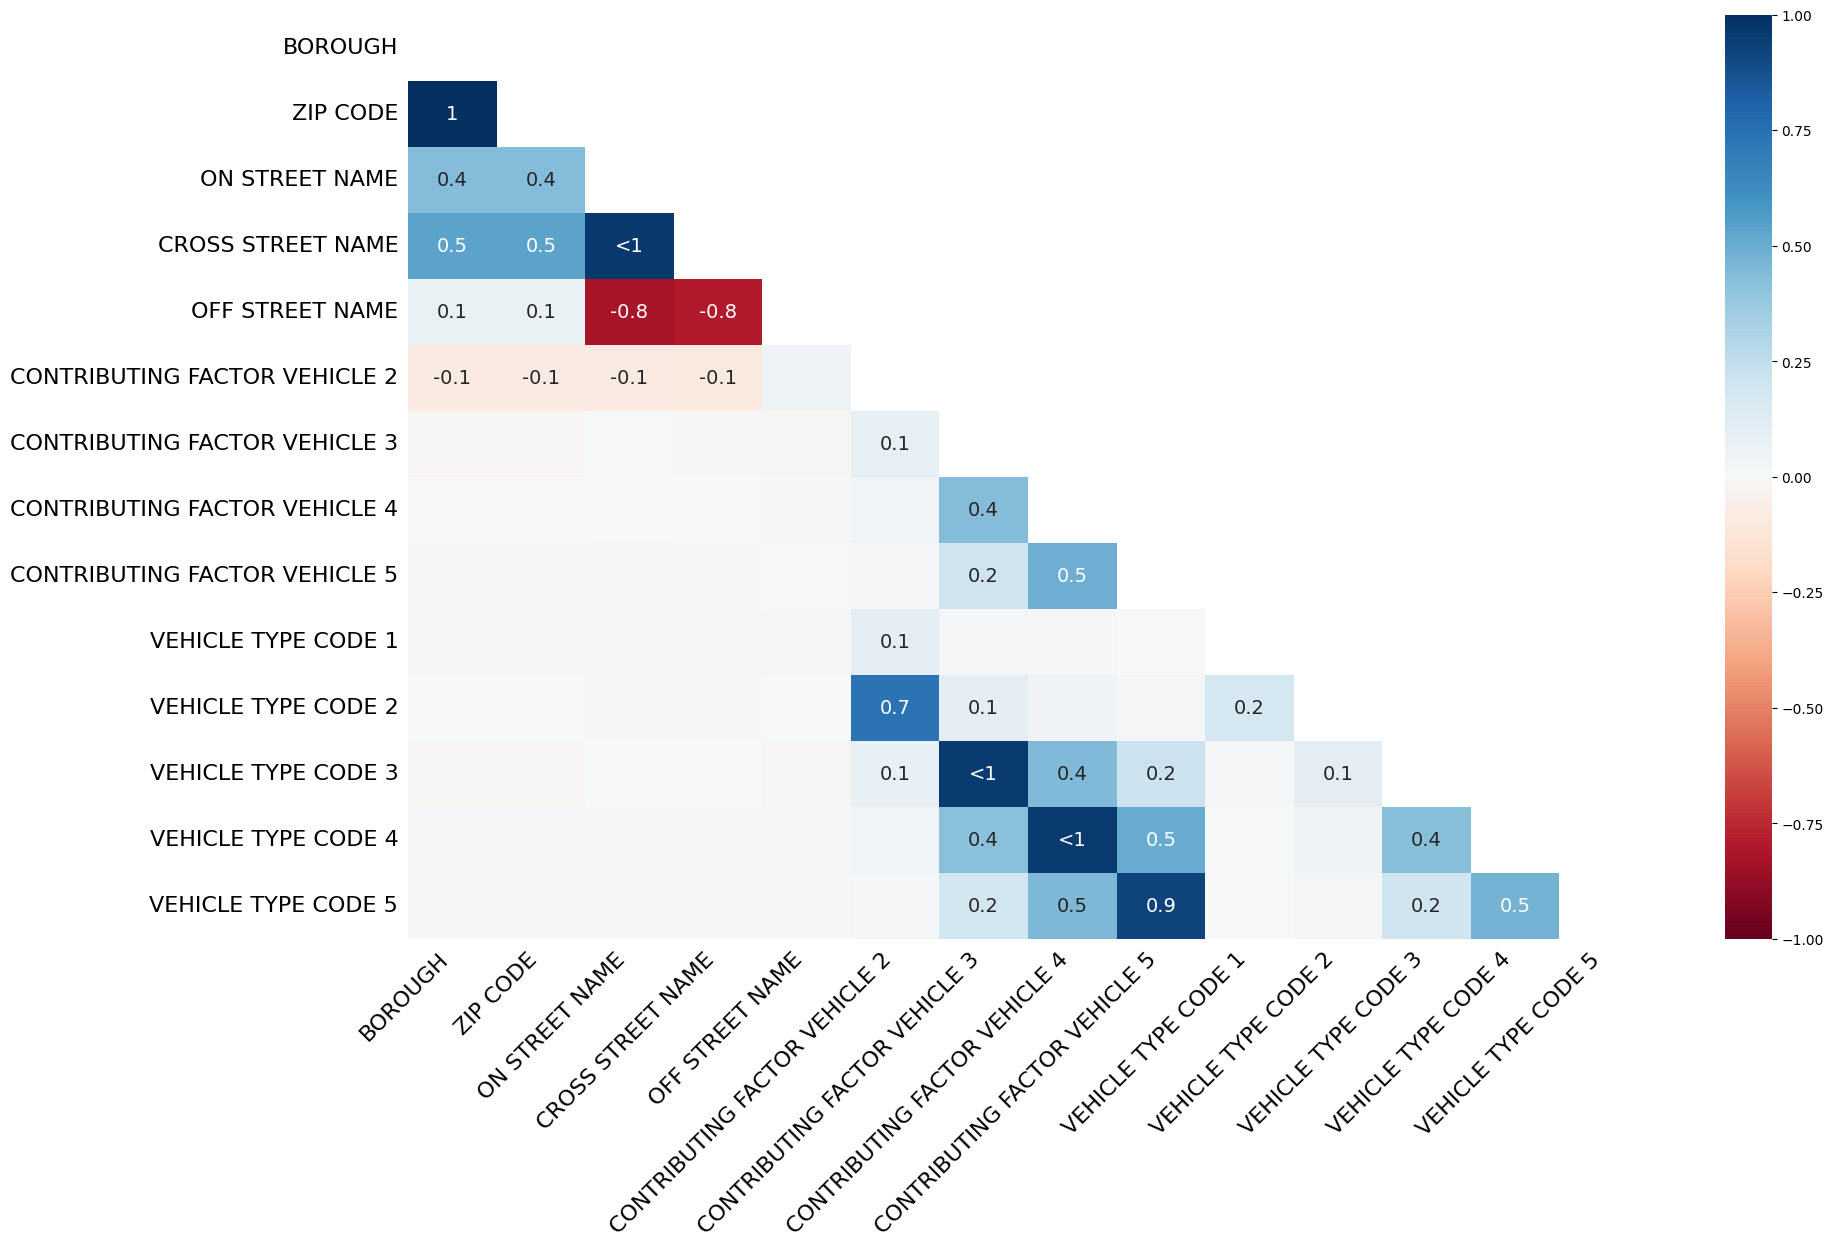

In [ ]:
# Mapa de calor de correlación entre valores faltantes
# Valores cercanos a -1 o 1 indican fuerte correlación en la ausencia de datos
# Valores cercanos a 0 indican que los valores faltantes no están relacionados
msno.heatmap(df)

<Axes: >

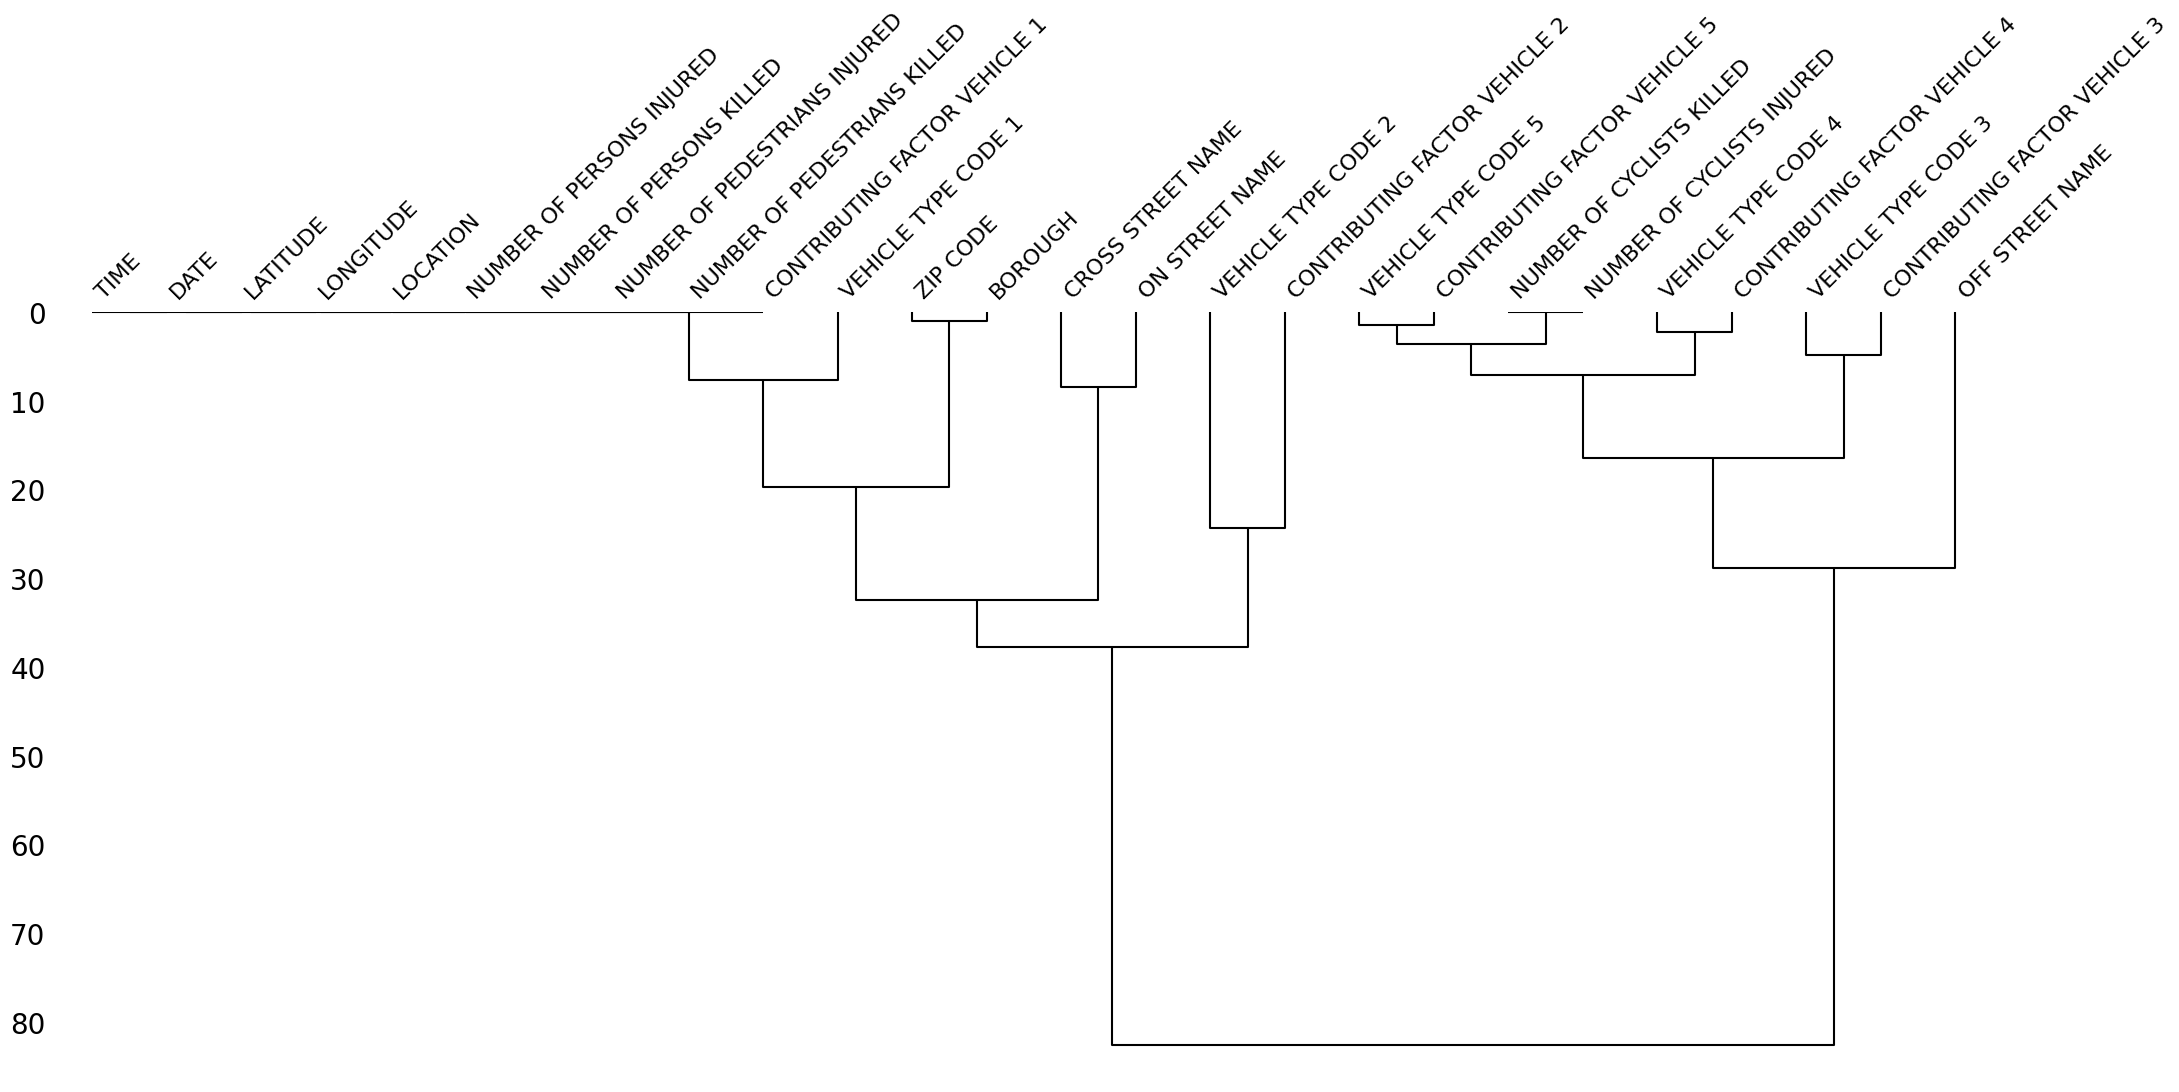

In [ ]:
# Dendrograma de correlación de valores faltantes
# Agrupa columnas según patrones similares de completitud/ausencia de datos
# Columnas agrupadas juntas tienden a tener valores faltantes en los mismos registros
msno.dendrogram(df)

### Interpretación del Dendrograma

El dendrograma es una visualización jerárquica que agrupa columnas según la **similitud de sus patrones de valores faltantes**.

**¿Cómo leerlo?**
- El **eje horizontal** muestra las columnas del dataset  
- El **eje vertical** representa una **distancia jerárquica** basada en la correlación de los patrones de valores faltantes  
- Las **líneas conectoras** unen columnas con patrones similares de valores faltantes  
- Cuanto **más baja** es la conexión, **más similares** son los patrones de ausencia de datos  

**¿Qué nos indica?**
- **Clusters con uniones a baja altura**:  
  - Las columnas tienden a tener valores faltantes en los mismos registros  
  - Esto sugiere que la ausencia de datos podría tener una causa común o estructural  
  - Ejemplo: Si "deck" y "age" se conectan a baja altura, cuando falta uno suele faltar el otro  

- **Clusters con uniones a mayor altura**:  
  - Las columnas presentan patrones de valores faltantes poco relacionados o independientes  
  - La ausencia de datos ocurre de forma más dispersa entre estas variables  

- **Grupos de variables**:  
  - Permiten identificar conjuntos de variables que “faltan juntas”  
  - Esto es útil para definir estrategias de imputación  
  - Variables con patrones de ausencia similares pueden requerir un tratamiento conjunto  

## Algunos insights

- **Variables de víctimas (heridos y fallecidos).**
Las variables relacionadas con personas y peatones heridos o fallecidos se agrupan a muy baja altura, lo que indica que sus valores faltantes ocurren de forma conjunta. Esto tiene sentido porque estos campos solo se completan cuando el evento genera víctimas; cuando no las hay, el sistema deja los campos vacíos. La ausencia, por tanto, es estructural y contiene información relevante.

- **Variables asociadas a vehículos involucrados.**
Los tipos de vehículo y factores contribuyentes para los vehículos 1 a 5 forman un cluster claro, reflejando que su ausencia depende del número de vehículos presentes en el incidente. Si un evento involucra menos vehículos, los campos correspondientes a vehículos adicionales quedan vacíos. Este patrón es coherente con el diseño del registro y no responde a datos faltantes aleatorios.

- **Variables de localización.**
Las variables de ubicación (borough, ZIP y nombres de calles) se agrupan porque funcionan como campos alternativos para describir el lugar del evento. Dependiendo del tipo de registro, se completa una combinación distinta de estos campos. Por ello, la ausencia de alguno no implica falta de información, sino una forma distinta de captura.

# Eliminación e Imputación de Valores Faltantes

Trabajaremos con el dataset del Titanic para demostrar diferentes estrategias de manejo de datos faltantes:

1. **Eliminación**: Cuando una columna tiene demasiados valores faltantes (>50%), puede ser mejor eliminarla
2. **Imputación simple**: Reemplazar valores faltantes con media, mediana o moda
3. **Imputación avanzada**: Usar modelos predictivos para estimar los valores faltantes

In [ ]:
# Cargar el dataset Titanic
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

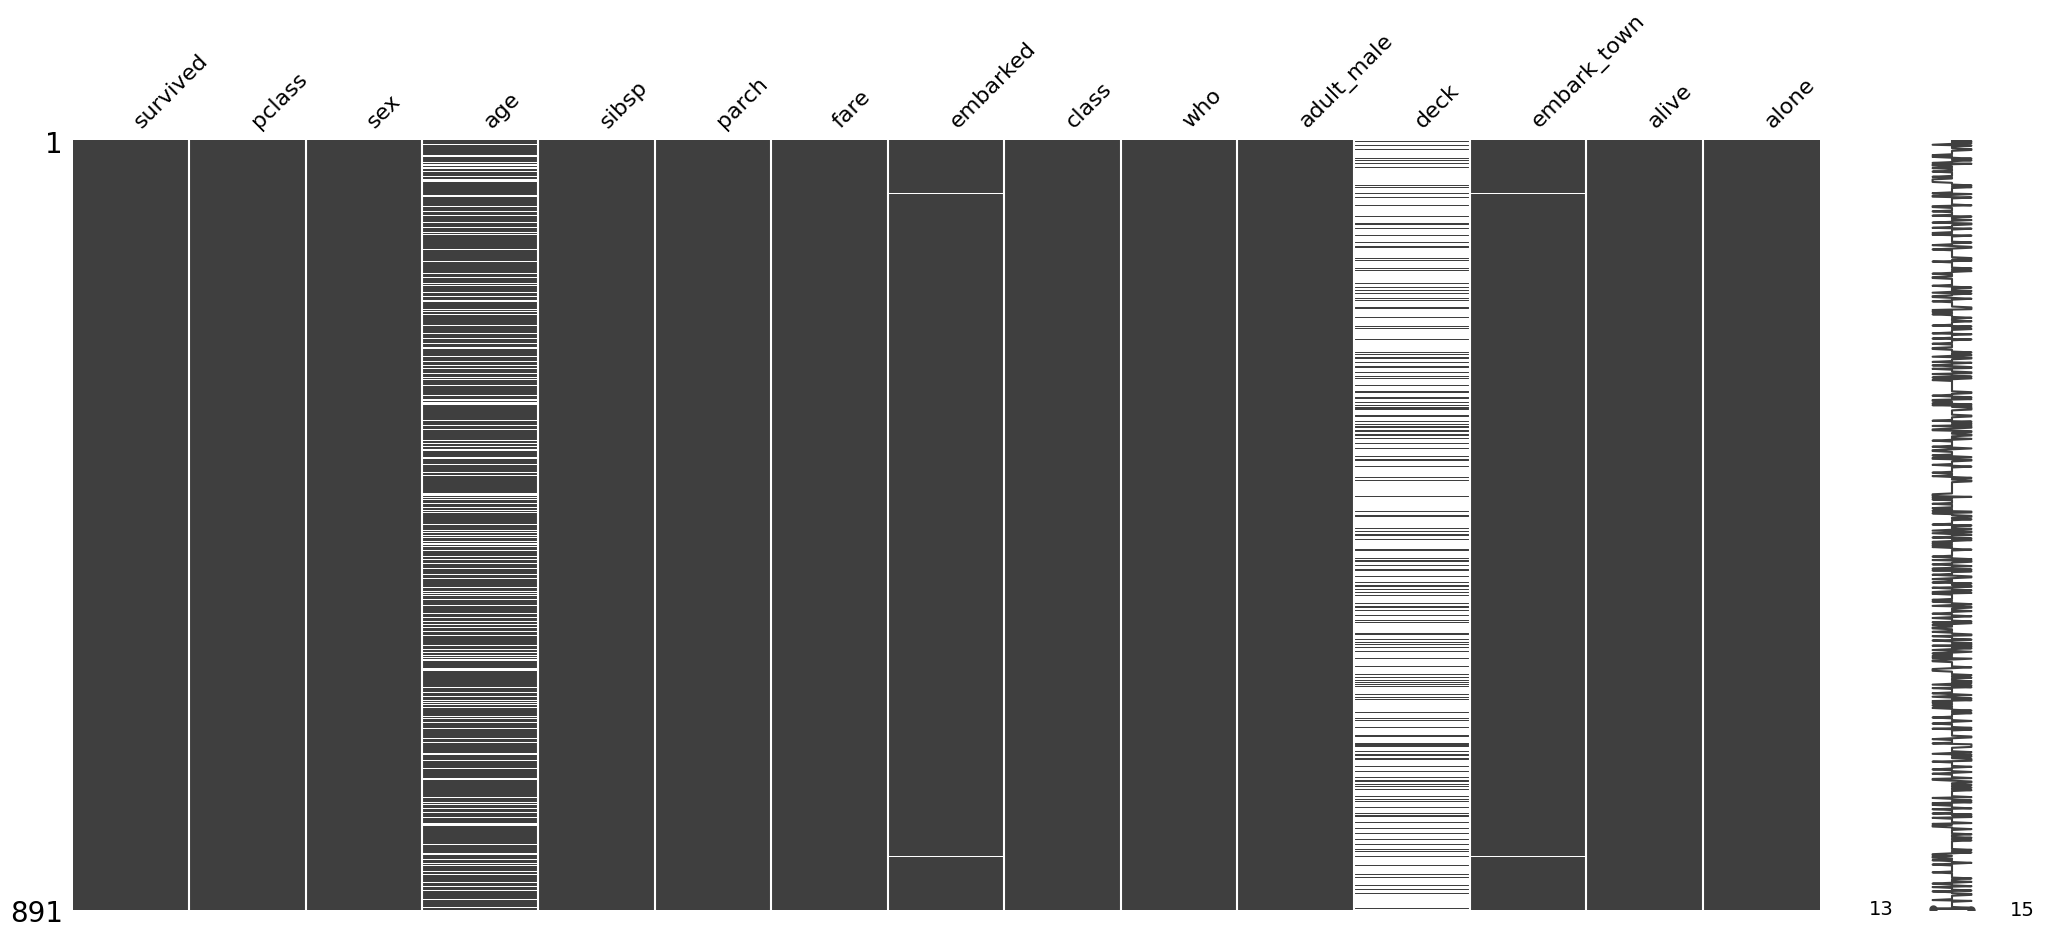

In [ ]:
# Visualización de valores faltantes en el dataset del Titanic
# Observamos que 'deck' y 'age' tienen cantidades significativas de datos faltantes
msno.matrix(df)

In [ ]:
# Función para analizar valores faltantes de forma cuantitativa
def check_missing_values(df):
    # Calcular valores faltantes y porcentaje
    missing_data = df.isnull().sum()
    missing_data_percentage = (missing_data / len(df)) * 100

    # Crear la tabla
    missing_data_table = pd.DataFrame({
        'Column': missing_data.index,
        'Missing Values': missing_data.values,
        'Missing Percentage (%)': missing_data_percentage.values
    })

    # Ordenar por porcentaje de valores faltantes
    missing_data_table = missing_data_table.sort_values(by='Missing Percentage (%)', ascending=False).reset_index(drop=True)

    return missing_data_table

# Análisis inicial: 'deck' tiene 77% de valores faltantes, 'age' tiene ~20%
check_missing_values(df)

,Column,Missing Values,Missing Percentage (%)
0,deck,688,77.216611
1,age,177,19.865320
2,embarked,2,0.224467
3,embark_town,2,0.224467
4,sex,0,0.000000
5,pclass,0,0.000000
6,survived,0,0.000000
7,fare,0,0.000000
8,parch,0,0.000000
9,sibsp,0,0.000000


### Eliminar Columnas con Exceso de Valores Faltantes

Cuando una columna tiene más del 50% de valores faltantes, generalmente es mejor eliminarla que intentar imputarla, ya que:
- La imputación podría introducir más ruido que información útil
- Tendríamos más datos artificiales que reales
- Podría sesgar nuestros modelos y análisis

In [ ]:
# Identificar las columnas con más del 50% de valores faltantes
threshold = 0.5
columns_to_drop = df.columns[df.isnull().mean() > threshold]

# Eliminar las columnas identificadas
df = df.drop(columns=columns_to_drop)

# Mostrar las columnas eliminadas y el dataframe resultante
print(f"Columnas eliminadas: {list(columns_to_drop)}")

Columnas eliminadas: ['deck']


### Imputaciones Simples

Las técnicas de imputación simple reemplazan valores faltantes con estadísticas descriptivas:

- **Media**: Útil para distribuciones simétricas sin outliers extremos
- **Mediana**: Más robusta ante valores atípicos, recomendada para distribuciones asimétricas
- **Moda**: Apropiada para variables categóricas o cuando queremos el valor más frecuente

Crearemos columnas separadas para comparar los diferentes métodos de imputación.

In [ ]:
from sklearn.impute import SimpleImputer

# Crear imputadores para la media, mediana y moda
imputer_mean = SimpleImputer(strategy='mean')  # Imputar con la media
imputer_median = SimpleImputer(strategy='median')  # Imputar con la mediana
imputer_mode = SimpleImputer(strategy='most_frequent')  # Imputar con la moda

# Crear nuevas columnas para las imputaciones
df['age_mean'] = imputer_mean.fit_transform(df[['age']])
df['age_median'] = imputer_median.fit_transform(df[['age']])
df['age_mode'] = imputer_mode.fit_transform(df[['age']])

df['embarked'] = imputer_mode.fit_transform(df[['embarked']]).ravel()
df['embark_town'] = imputer_mode.fit_transform(df[['embark_town']]).ravel()

### Imputaciones Avanzadas

Las técnicas avanzadas utilizan modelos predictivos para estimar valores faltantes basándose en las relaciones entre variables:

1. **Regresión Lineal**: Predice valores faltantes usando una relación lineal con otras variables
2. **K-Nearest Neighbors (KNN)**: Usa el promedio de los k vecinos más cercanos en el espacio de características
3. **MICE (Multiple Imputation by Chained Equations)**: Método iterativo que imputa cada variable usando las demás como predictores

Estas técnicas suelen producir mejores resultados que las imputaciones simples, especialmente cuando existe correlación entre variables.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

# ------------------
# 1. Imputación por Regresión
# ------------------
features = ['pclass', 'sibsp', 'parch', 'fare']
df_regression = df[features + ['age']].dropna()

X = df_regression[features]
y = df_regression['age']

# Entrenar modelo de regresión
regressor = LinearRegression()
regressor.fit(X, y)

# Predecir valores faltantes
def predict_age(row):
    if pd.isnull(row['age']):
        row_data = pd.DataFrame([[row['pclass'], row['sibsp'], row['parch'], row['fare']]], columns=features)
        return regressor.predict(row_data)[0]
    return row['age']

df['age_regression'] = df.apply(predict_age, axis=1)

# ------------------
# 2. Imputación por KNN
# ------------------
knn_imputer = KNeighborsRegressor(n_neighbors=5)
knn_imputer.fit(X, y)

def predict_age_knn(row):
    if pd.isnull(row['age']):
        row_data = pd.DataFrame([[row['pclass'], row['sibsp'], row['parch'], row['fare']]], columns=features)
        return knn_imputer.predict(row_data)[0]
    return row['age']

df['age_knn'] = df.apply(predict_age_knn, axis=1)

# ------------------
# 3. Imputación por MICE
# ------------------
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_values = mice_imputer.fit_transform(df[features + ['age']])

# Crear la columna imputada con MICE
df['age_mice'] = imputed_values[:, -1]

### Comparación de los Métodos de Imputación

Ahora comparemos los valores imputados para las edades que originalmente estaban faltantes. Esto nos permitirá ver cómo difieren los métodos y cuál podría ser más apropiado según el contexto.

In [ ]:
# Comparación de valores imputados para registros que originalmente tenían edad faltante
df_missing_age = df[df['age'].isnull()]
df_missing_age[["age","age_mean", "age_median","age_mode","age_regression","age_knn","age_mice"]].head()

,age,age_mean,age_median,age_mode,age_regression,age_knn,age_mice
5,NaN,29.699118,28.0,24.0,27.525206,24.8,27.617131
17,NaN,29.699118,28.0,24.0,34.211637,32.7,34.111643
19,NaN,29.699118,28.0,24.0,27.549701,32.5,27.639522
26,NaN,29.699118,28.0,24.0,27.549701,32.5,27.639522
28,NaN,29.699118,28.0,24.0,27.536708,27.8,27.627645


### Interpretación de Resultados de Imputación

Observamos diferencias importantes entre los métodos:

**Métodos Simples:**
- **Media (29.7 años)**: Todos los valores faltantes reciben el mismo valor, ignorando el contexto individual
- **Mediana (28 años)**: Similar a la media, pero más robusta ante valores extremos
- **Moda (24 años)**: Usa el valor más frecuente, lo que puede no ser representativo para todos los casos

**Métodos Avanzados:**
- **Regresión, KNN y MICE**: Producen valores diferentes para cada pasajero, considerando características como clase, tarifa, número de hermanos/cónyuges, etc.
- Estos métodos capturan mejor la variabilidad real de los datos
- Por ejemplo, pasajeros de primera clase tienden a recibir edades imputadas más altas que los de tercera clase

**Nota importante**: Los métodos avanzados pueden producir valores negativos (como vemos en el resumen con -6.7 años en regresión), lo que indica que necesitaríamos post-procesar para asegurar valores válidos.

In [ ]:
# Verificamos si ahora existen valores faltantes
check_missing_values(df)

,Column,Missing Values,Missing Percentage (%)
0,age,177,19.86532
1,survived,0,0.00000
2,pclass,0,0.00000
3,sex,0,0.00000
4,sibsp,0,0.00000
5,parch,0,0.00000
6,fare,0,0.00000
7,embarked,0,0.00000
8,class,0,0.00000
9,who,0,0.00000


In [ ]:
# Mostrar un resumen del dataset después de la imputación
print("\nResumen del dataset después de la imputación:")
df.describe()


Resumen del dataset después de la imputación:


,survived,pclass,age,sibsp,parch,fare,age_mean,age_median,age_mode,age_regression,age_knn,age_mice
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,29.699118,29.361582,28.566970,29.280690,29.904308,29.292394
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,13.002015,13.019697,13.199572,13.629818,13.368853,13.607958
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.420000,0.420000,0.420000,-6.700118,0.420000,-6.156028
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,22.000000,22.000000,22.000000,22.000000,21.750000,22.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,29.699118,28.000000,24.000000,27.539522,29.600000,27.630218
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,35.000000,35.000000,35.000000,36.000000,37.000000,36.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000


## Conclusiones y Recomendaciones

### Consideraciones importantes:

- **No existe un método universalmente mejor**: Cada dataset y problema requiere un análisis específico
- **Validar resultados**: Siempre revisa los valores imputados para detectar anomalías (ej: edades negativas)
- **Documentar decisiones**: Registra qué método usaste y por qué, esto es crucial para la reproducibilidad
- **Evaluar impacto**: Compara el rendimiento de tu modelo con diferentes métodos de imputación

### Estadísticas finales del dataset:

Como observamos en el resumen final, después de las imputaciones:
- La media de edad se mantuvo relativamente estable entre métodos (~29-30 años)
- Los métodos avanzados preservan mejor la desviación estándar original
- KNN produjo valores más conservadores (sin valores negativos)
- MICE y Regresión fueron más agresivos pero capturaron mejor las relaciones entre variables